In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# SET DATA PATH
DATA_EXACT_PATH = "../../data/simulations-exact.h5"
DATA_LINEAR_PATH = "../../data/simulations-linear.h5"
DATA_QUADRATIC_PATH = "../../data/simulations-quadratic.h5"

In [ ]:
# Check whether everything inside is ok
with h5py.File(DATA_EXACT_PATH, "r") as f:
    print(f.keys())
    print(f['layer_0'].keys())
    print(f['layer_0']['f'])
    print(f['layer_0']['q'])
    print(f['layer_0']['v'])
    print(f['layer_0']['bold'])

<KeysViewHDF5 ['layer_0', 'layer_1', 'layer_2', 'meta']>
<KeysViewHDF5 ['bold', 'f', 'q', 'q_star', 's', 'v', 'v_star', 'x']>
<HDF5 dataset "f": shape (100, 10, 32, 32), type "<f2">
<HDF5 dataset "q": shape (100, 10, 32, 32), type "<f2">
<HDF5 dataset "v": shape (100, 10, 32, 32), type "<f2">
<HDF5 dataset "bold": shape (100, 100, 32, 32), type "<f2">


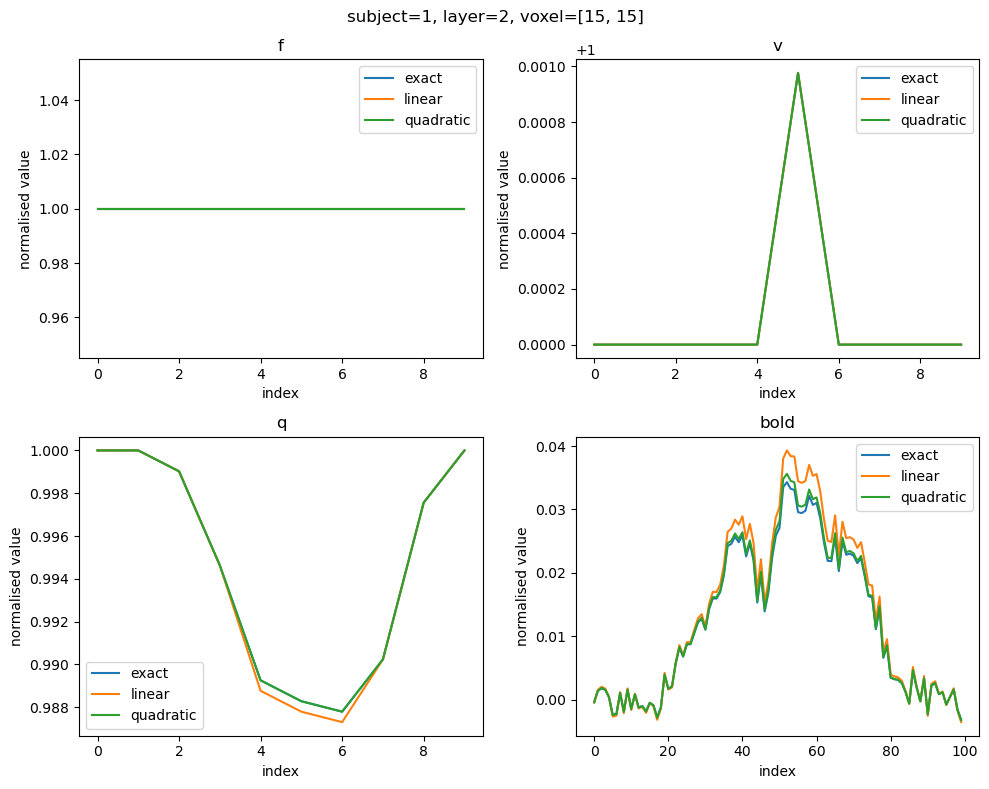

In [ ]:
# Plot observables

sub = 1
layer = 2
post = [15, 15]

variables = ["f", "v", "q", "bold"]

data = {}
for var in variables:
    lay = f"layer_{layer}"
    with h5py.File(DATA_EXACT_PATH, "r") as f:
        data[f"exact_{var}"] = f[lay][var][sub, :, *post]
    with h5py.File(DATA_LINEAR_PATH, "r") as f:
        data[f"linear_{var}"] = f[lay][var][sub, :, *post]
    with h5py.File(DATA_QUADRATIC_PATH, "r") as f:
        data[f"quadratic_{var}"] = f[lay][var][sub, :, *post]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]
    ax.plot(data[f"exact_{var}"], label="exact")
    ax.plot(data[f"linear_{var}"], label="linear")
    ax.plot(data[f"quadratic_{var}"], label="quadratic")
    ax.set_title(var)
    ax.set_xlabel("index")
    ax.set_ylabel("normalised value")
    ax.legend()

plt.suptitle(f"subject={sub}, layer={layer}, voxel={post}")
plt.tight_layout()
plt.savefig(f'figs/simulation-sub-{sub}-layer-{layer}-voxel-{post}.png', dpi=300)